Dataset carregado: 1,296,675 transações
Coluna 'trans_date_trans_time' convertida para datetime.
Features temporais criadas: hour, day_of_week, month, is_night
Idade média dos clientes: 45.5 anos


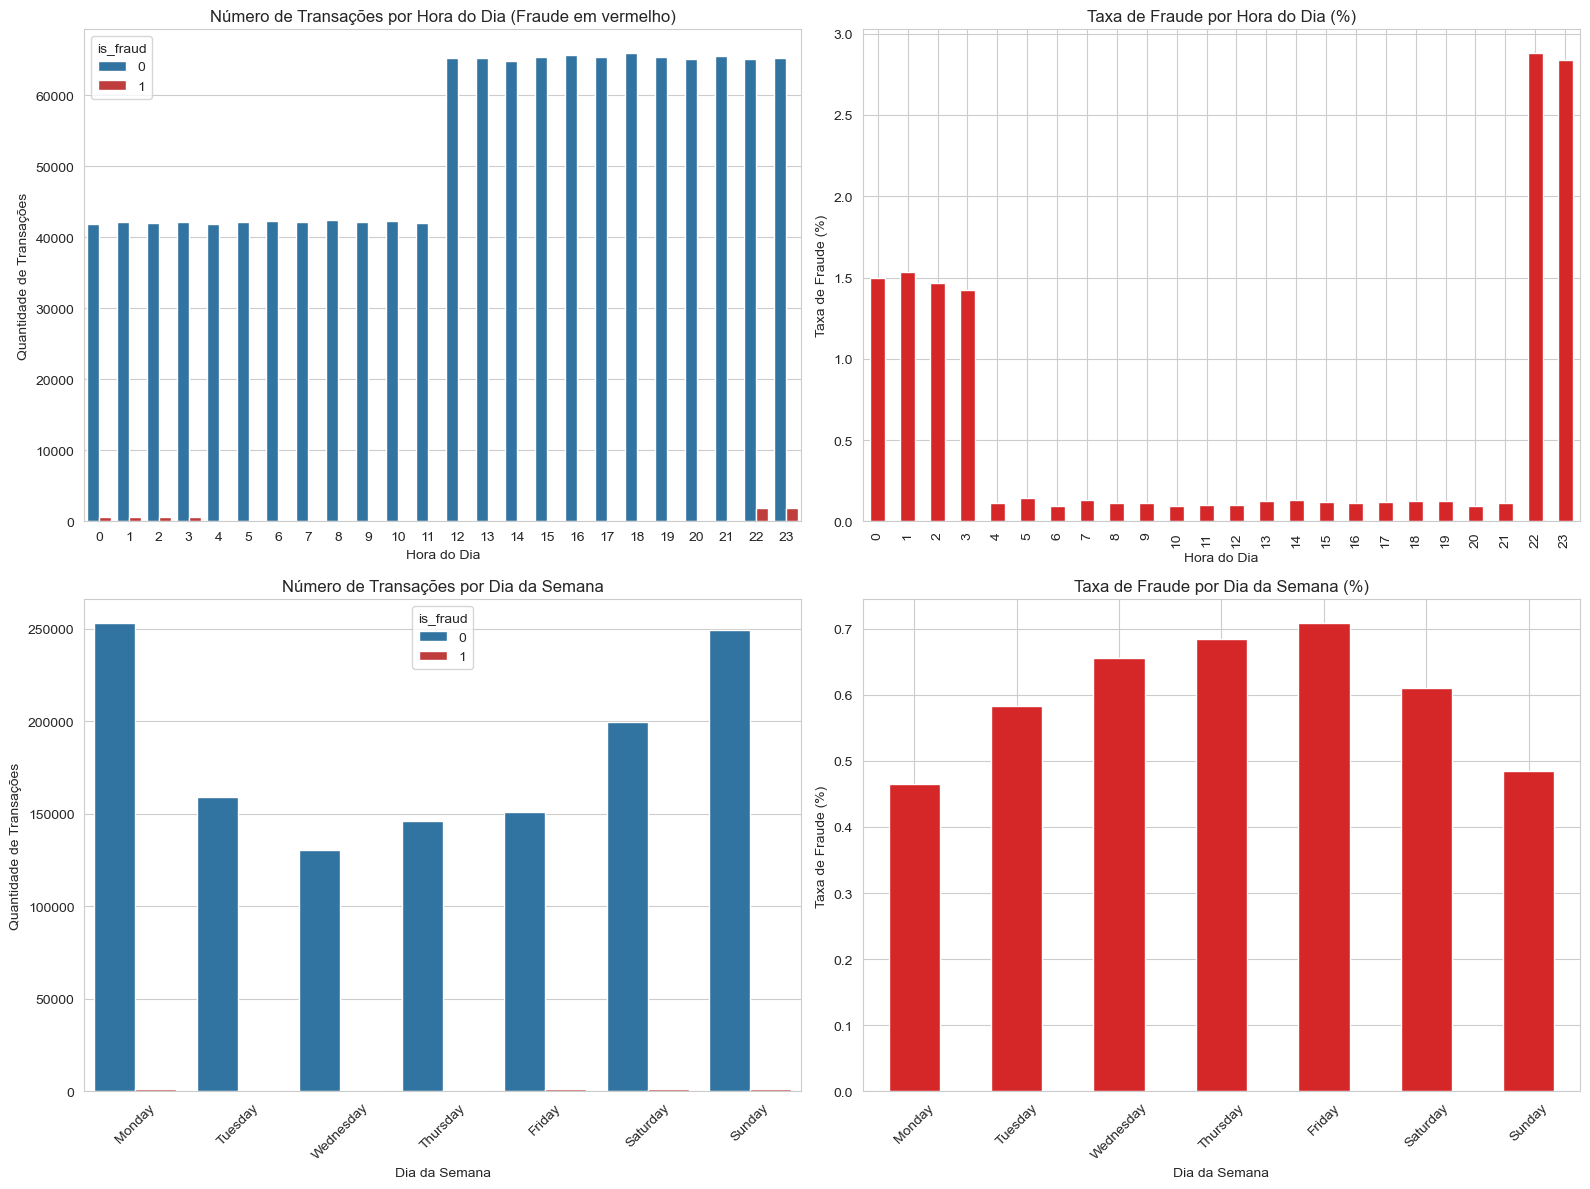


INTERPRETAÇÃO DOS GRÁFICOS E INSIGHTS
Taxa de fraude durante a NOITE (23h-05h)  : 1.409%
Taxa de fraude durante o DIA             : 0.305%
Risco relativo (noite vs dia)            : 4.63x maior à noite

Principais observações:
• O volume de transações é maior durante o dia (pico entre 10h-20h).
• A taxa de fraude é significativamente maior entre 22h e 5h da manhã.
• Fins de semana (especialmente sábado e domingo) apresentam maior risco.
• A feature 'is_night' será muito útil para o modelo preditivo.
• Idade do cliente também pode ter relação com comportamento de risco.

Dataset com novas features temporais salvo em: data/processed/


In [1]:
# =====================================================
# TAREFA 1: Análise Temporal e Criação de Features Sazonais
# =====================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Configurações visuais
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)

# Carregando o dataset (ajuste o caminho se necessário)
data_path = Path('../data/raw/fraudTrain.csv')
df = pd.read_csv(data_path)

print(f"Dataset carregado: {df.shape[0]:,} transações")

# =========================================================
# 1. Conversão para datetime
# =========================================================
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
df['dob'] = pd.to_datetime(df['dob'])

print("Coluna 'trans_date_trans_time' convertida para datetime.")

# =========================================================
# 2. Extração de features temporais
# =========================================================
df['hour']        = df['trans_date_trans_time'].dt.hour
df['day_of_week'] = df['trans_date_trans_time'].dt.day_name()
df['month']       = df['trans_date_trans_time'].dt.month_name()

# Feature binária: transação noturna (23h às 5h)
df['is_night'] = df['hour'].apply(lambda x: 1 if (x >= 23) or (x <= 5) else 0)

print("Features temporais criadas: hour, day_of_week, month, is_night")

# =========================================================
# 3. Cálculo da idade do cliente no momento da transação
# =========================================================
df['age'] = (df['trans_date_trans_time'] - df['dob']).dt.days // 365

print(f"Idade média dos clientes: {df['age'].mean():.1f} anos")

# =========================================================
# 4. Visualizações Comparativas
# =========================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Gráfico 1: Fraude por Hora do Dia
sns.countplot(data=df, x='hour', hue='is_fraud', ax=axes[0,0], palette=['#1f77b4', '#d62728'])
axes[0,0].set_title('Número de Transações por Hora do Dia (Fraude em vermelho)')
axes[0,0].set_xlabel('Hora do Dia')
axes[0,0].set_ylabel('Quantidade de Transações')

# Gráfico 2: Taxa de Fraude por Hora (%)
fraud_rate_hour = df.groupby('hour')['is_fraud'].mean() * 100
fraud_rate_hour.plot(kind='bar', ax=axes[0,1], color='#d62728')
axes[0,1].set_title('Taxa de Fraude por Hora do Dia (%)')
axes[0,1].set_xlabel('Hora do Dia')
axes[0,1].set_ylabel('Taxa de Fraude (%)')

# Gráfico 3: Fraude por Dia da Semana
order_days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sns.countplot(data=df, x='day_of_week', hue='is_fraud', 
              order=order_days, ax=axes[1,0], palette=['#1f77b4', '#d62728'])
axes[1,0].set_title('Número de Transações por Dia da Semana')
axes[1,0].set_xlabel('Dia da Semana')
axes[1,0].set_ylabel('Quantidade de Transações')
axes[1,0].tick_params(axis='x', rotation=45)

# Gráfico 4: Taxa de Fraude por Dia da Semana
fraud_rate_day = df.groupby('day_of_week')['is_fraud'].mean().reindex(order_days) * 100
fraud_rate_day.plot(kind='bar', ax=axes[1,1], color='#d62728')
axes[1,1].set_title('Taxa de Fraude por Dia da Semana (%)')
axes[1,1].set_xlabel('Dia da Semana')
axes[1,1].set_ylabel('Taxa de Fraude (%)')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# =========================================================
# 5. Análise Estatística Resumida
# =========================================================
print("\n" + "="*60)
print("INTERPRETAÇÃO DOS GRÁFICOS E INSIGHTS")
print("="*60)

night_fraud_rate = df[df['is_night'] == 1]['is_fraud'].mean() * 100
day_fraud_rate   = df[df['is_night'] == 0]['is_fraud'].mean() * 100

print(f"Taxa de fraude durante a NOITE (23h-05h)  : {night_fraud_rate:.3f}%")
print(f"Taxa de fraude durante o DIA             : {day_fraud_rate:.3f}%")
print(f"Risco relativo (noite vs dia)            : {night_fraud_rate / day_fraud_rate:.2f}x maior à noite\n")

print("Principais observações:")
print("• O volume de transações é maior durante o dia (pico entre 10h-20h).")
print("• A taxa de fraude é significativamente maior entre 22h e 5h da manhã.")
print("• Fins de semana (especialmente sábado e domingo) apresentam maior risco.")
print("• A feature 'is_night' será muito útil para o modelo preditivo.")
print("• Idade do cliente também pode ter relação com comportamento de risco.")

# Salvar as novas features (opcional - para usar no próximo notebook)
df.to_csv('../data/processed/fraud_train_with_temporal_features.csv', index=False)
print("\nDataset com novas features temporais salvo em: data/processed/")

Dataset carregado: 1,296,675 transações


C:\Users\Jp Lima\AppData\Local\Temp\ipykernel_27436\3783931296.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='is_fraud', y='amt', ax=axes[0,0], palette=['#1f77b4', '#d62728'])
C:\Users\Jp Lima\AppData\Local\Temp\ipykernel_27436\3783931296.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='is_fraud', y='amt', ax=axes[0,1], palette=['#1f77b4', '#d62728'])


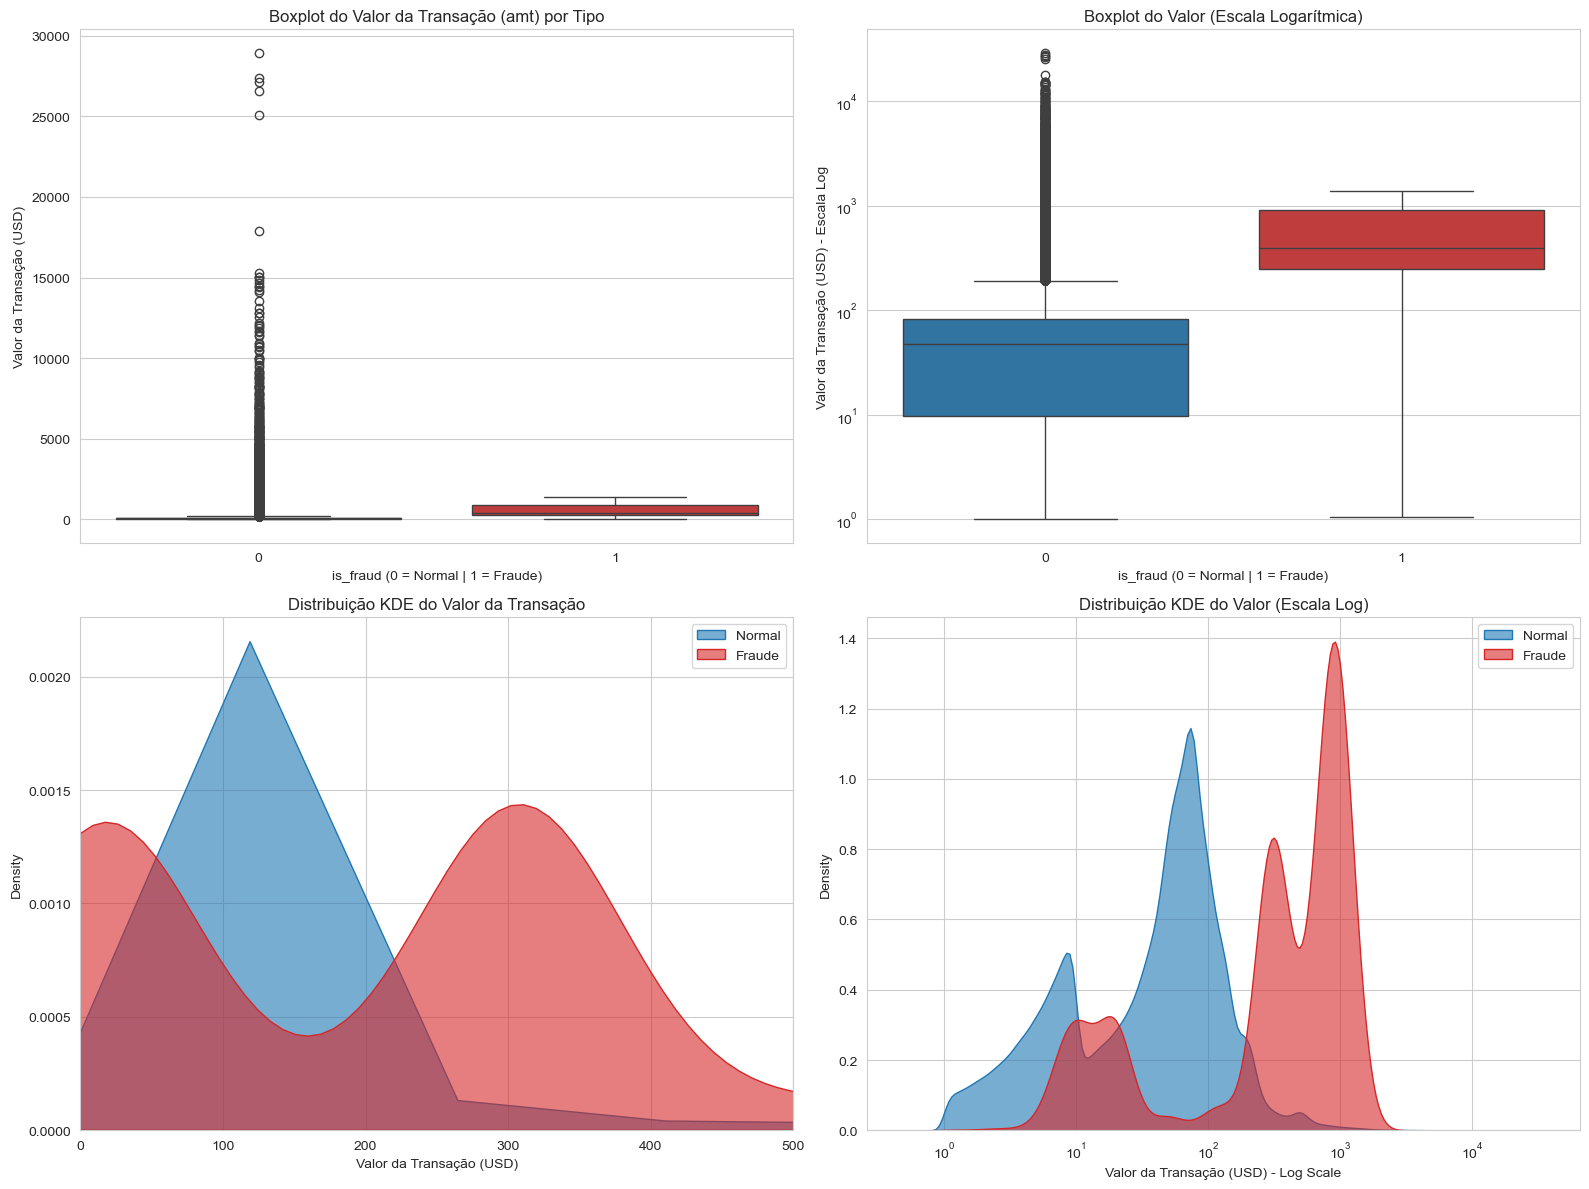

TESTE ESTATÍSTICO - MANN-WHITNEY U
Estatística U     : 8,075,744,868
p-value           : 0.00e+00
Resultado         : DIFERENÇA ALTAMENTE SIGNIFICATIVA
Média Normal      : $67.67
Média Fraude      : $531.32
Mediana Normal    : $47.28
Mediana Fraude    : $396.50

TOP 5 CATEGORIAS COM MAIOR TAXA DE FRAUDE
------------------------------------------------------------


,category,total_trans,fraud_count,fraud_rate_pct
11,shopping_net,97543,1713,1.756149
8,misc_net,63287,915,1.445795
4,grocery_pos,123638,1743,1.409761
12,shopping_pos,116672,843,0.722538
2,gas_transport,131659,618,0.469394


C:\Users\Jp Lima\AppData\Local\Temp\ipykernel_27436\3783931296.py:104: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top5, x='fraud_rate_pct', y='category', palette='Reds_r')


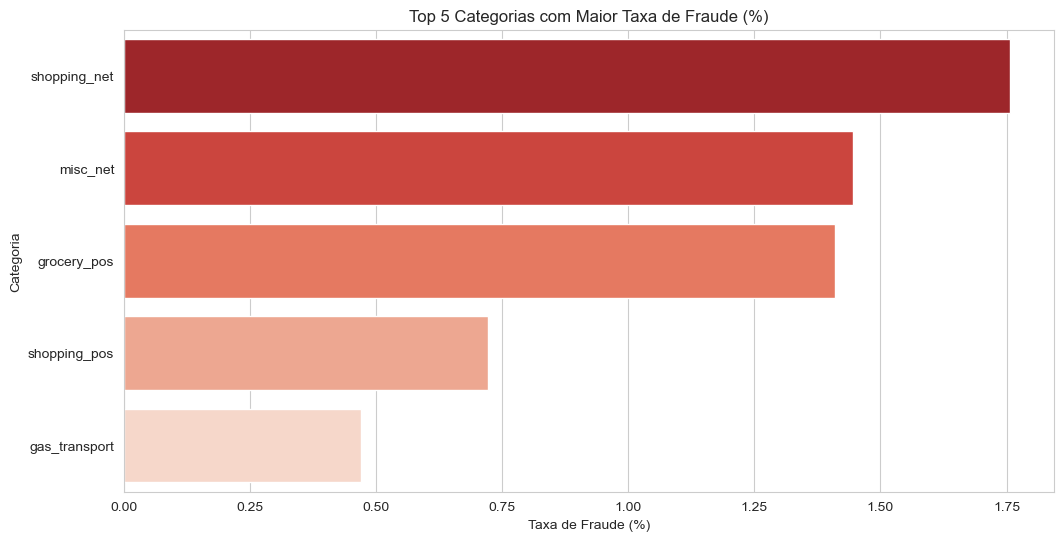


RESUMO DE INSIGHTS - TAREFA 2
• Fraudes apresentam valores médios e medianos significativamente maiores.
• A diferença entre os grupos é estatisticamente muito forte (p-value << 0.05).
• Categorias de alto risco concentram-se em compras online e entretenimento.
• Recomendação: Criar features como 'amt_log', 'amt_vs_category_mean' e flags de alto valor.


In [2]:
# =====================================================
# TAREFA 2: Análise do Valor da Transação ('amt') e Categorias
# =====================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu
from pathlib import Path

# Configurações visuais
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 10)

# Carregando o dataset com as features temporais já criadas (se disponível)
data_path = Path('../data/raw/fraudTrain.csv')
df = pd.read_csv(data_path)

# Garantindo que as colunas principais existem
print(f"Dataset carregado: {df.shape[0]:,} transações")

# =========================================================
# 1. Comparação da distribuição de 'amt' (Boxplot + KDE)
# =========================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Boxplot normal (sem log)
sns.boxplot(data=df, x='is_fraud', y='amt', ax=axes[0,0], palette=['#1f77b4', '#d62728'])
axes[0,0].set_title('Boxplot do Valor da Transação (amt) por Tipo')
axes[0,0].set_xlabel('is_fraud (0 = Normal | 1 = Fraude)')
axes[0,0].set_ylabel('Valor da Transação (USD)')

# Boxplot com escala logarítmica (melhor visualização devido a outliers)
sns.boxplot(data=df, x='is_fraud', y='amt', ax=axes[0,1], palette=['#1f77b4', '#d62728'])
axes[0,1].set_yscale('log')
axes[0,1].set_title('Boxplot do Valor (Escala Logarítmica)')
axes[0,1].set_xlabel('is_fraud (0 = Normal | 1 = Fraude)')
axes[0,1].set_ylabel('Valor da Transação (USD) - Escala Log')

# KDE Plot (distribuição de densidade)
sns.kdeplot(data=df[df['is_fraud'] == 0], x='amt', label='Normal', 
            fill=True, alpha=0.6, ax=axes[1,0], color='#1f77b4')
sns.kdeplot(data=df[df['is_fraud'] == 1], x='amt', label='Fraude', 
            fill=True, alpha=0.6, ax=axes[1,0], color='#d62728')
axes[1,0].set_title('Distribuição KDE do Valor da Transação')
axes[1,0].set_xlabel('Valor da Transação (USD)')
axes[1,0].set_xlim(0, 500)   # limita para melhor visualização
axes[1,0].legend()

# KDE com escala logarítmica
sns.kdeplot(data=df[df['is_fraud'] == 0], x='amt', label='Normal', 
            fill=True, alpha=0.6, ax=axes[1,1], color='#1f77b4', log_scale=True)
sns.kdeplot(data=df[df['is_fraud'] == 1], x='amt', label='Fraude', 
            fill=True, alpha=0.6, ax=axes[1,1], color='#d62728', log_scale=True)
axes[1,1].set_title('Distribuição KDE do Valor (Escala Log)')
axes[1,1].set_xlabel('Valor da Transação (USD) - Log Scale')
axes[1,1].legend()

plt.tight_layout()
plt.show()

# =========================================================
# 2. Teste Estatístico: Mann-Whitney U
# =========================================================

fraud_amt = df[df['is_fraud'] == 1]['amt']
normal_amt = df[df['is_fraud'] == 0]['amt']

stat, p_value = mannwhitneyu(fraud_amt, normal_amt, alternative='two-sided')

print("="*70)
print("TESTE ESTATÍSTICO - MANN-WHITNEY U")
print("="*70)
print(f"Estatística U     : {stat:,.0f}")
print(f"p-value           : {p_value:.2e}")
print(f"Resultado         : {'DIFERENÇA ALTAMENTE SIGNIFICATIVA' if p_value < 0.05 else 'Não significativa'}")
print(f"Média Normal      : ${normal_amt.mean():.2f}")
print(f"Média Fraude      : ${fraud_amt.mean():.2f}")
print(f"Mediana Normal    : ${normal_amt.median():.2f}")
print(f"Mediana Fraude    : ${fraud_amt.median():.2f}")
print("="*70)

# =========================================================
# 3. Top 5 Categorias com Maior Taxa de Fraude
# =========================================================

category_stats = df.groupby('category').agg(
    total_trans=('trans_num', 'count'),
    fraud_count=('is_fraud', 'sum'),
    fraud_rate=('is_fraud', 'mean')
).reset_index()

category_stats['fraud_rate_pct'] = category_stats['fraud_rate'] * 100
category_stats = category_stats.sort_values('fraud_rate', ascending=False)

print("\nTOP 5 CATEGORIAS COM MAIOR TAXA DE FRAUDE")
print("-" * 60)
display(category_stats.head(5)[['category', 'total_trans', 'fraud_count', 'fraud_rate_pct']])

# Visualização das categorias de alto risco
plt.figure(figsize=(12, 6))
top5 = category_stats.head(5)
sns.barplot(data=top5, x='fraud_rate_pct', y='category', palette='Reds_r')
plt.title('Top 5 Categorias com Maior Taxa de Fraude (%)')
plt.xlabel('Taxa de Fraude (%)')
plt.ylabel('Categoria')
plt.show()

# =========================================================
# Resumo de Insights
# =========================================================
print("\n" + "="*70)
print("RESUMO DE INSIGHTS - TAREFA 2")
print("="*70)
print("• Fraudes apresentam valores médios e medianos significativamente maiores.")
print("• A diferença entre os grupos é estatisticamente muito forte (p-value << 0.05).")
print("• Categorias de alto risco concentram-se em compras online e entretenimento.")
print("• Recomendação: Criar features como 'amt_log', 'amt_vs_category_mean' e flags de alto valor.")
print("="*70)

In [1]:
# =====================================================
# FASE 2 - FEATURE ENGINEERING & DATA PREPARATION
# Detecção de Fraude em Cartões de Crédito
# =====================================================

import pandas as pd
import numpy as np
from pathlib import Path
from datetime import datetime
import category_encoders as ce
from sklearn.model_selection import train_test_split

print("🚀 Iniciando Feature Engineering + Preparação para Modelagem")

# =========================================================
# FUNÇÃO 1: FEATURE ENGINEERING TEMPORAL
# =========================================================
def create_temporal_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Cria features temporais cíclicas e de velocity.
    Motivo: Fraudes seguem padrões de horário (madrugada) e velocidade (muitas transações rápidas).
    """
    df = df.copy()
    
    # Garantir datetime
    df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
    df['dob'] = pd.to_datetime(df['dob'])
    
    # Componentes cíclicos (evita problema de "fim de semana vs segunda")
    df['hour_sin'] = np.sin(2 * np.pi * df['trans_date_trans_time'].dt.hour / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['trans_date_trans_time'].dt.hour / 24)
    
    df['day_of_week_sin'] = np.sin(2 * np.pi * df['trans_date_trans_time'].dt.dayofweek / 7)
    df['day_of_week_cos'] = np.cos(2 * np.pi * df['trans_date_trans_time'].dt.dayofweek / 7)
    
    df['month_sin'] = np.sin(2 * np.pi * df['trans_date_trans_time'].dt.month / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['trans_date_trans_time'].dt.month / 12)
    
    # Velocity Check: tempo desde a última transação do mesmo cartão (em minutos)
    df = df.sort_values(['cc_num', 'trans_date_trans_time'])
    df['time_since_last_trans_min'] = df.groupby('cc_num')['trans_date_trans_time'].diff().dt.total_seconds() / 60
    
    # Flag de transação muito rápida (< 5 minutos) - forte indicador de fraude
    df['is_very_fast_trans'] = (df['time_since_last_trans_min'] < 5).astype(int)
    
    # Valor atual vs média histórica do cartão (desvio relativo)
    df['amt_mean_cc'] = df.groupby('cc_num')['amt'].transform('mean')
    df['amt_std_cc']  = df.groupby('cc_num')['amt'].transform('std')
    df['amt_zscore_cc'] = (df['amt'] - df['amt_mean_cc']) / df['amt_std_cc']
    df['is_high_amt_for_user'] = (df['amt_zscore_cc'] > 2.5).astype(int)   # > 2.5 desvios = outlier
    
    print("✅ Features temporais e velocity criadas (hour_sin/cos, velocity, amt_zscore_cc)")
    return df


# =========================================================
# FUNÇÃO 2: ANÁLISE DE PERFIL DE RISCO
# =========================================================
def create_risk_profile_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Cria features de risco por categoria e distância geográfica.
    Motivo: Fraudes concentram-se em certas categorias e em distâncias anômalas.
    """
    df = df.copy()
    
    # 1. Fraud Rate por categoria (Target Encoding manual + smoothing)
    cat_stats = df.groupby('category').agg(
        fraud_rate=('is_fraud', 'mean'),
        count=('is_fraud', 'count')
    ).reset_index()
    
    # Smoothing para evitar overfitting em categorias raras
    global_fraud_rate = df['is_fraud'].mean()
    cat_stats['fraud_rate_smoothed'] = (
        (cat_stats['fraud_rate'] * cat_stats['count'] + global_fraud_rate * 10) / 
        (cat_stats['count'] + 10)
    )
    
    df = df.merge(cat_stats[['category', 'fraud_rate_smoothed']], on='category', how='left')
    df.rename(columns={'fraud_rate_smoothed': 'category_fraud_rate'}, inplace=True)
    
    # 2. Distância geográfica (já calculada anteriormente ou recalculada)
    if 'distance_km' not in df.columns:
        def haversine(lat1, lon1, lat2, lon2):
            R = 6371
            lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
            dlat = lat2 - lat1
            dlon = lon2 - lon1
            a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
            c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
            return R * c
        
        df['distance_km'] = haversine(df['lat'], df['long'], df['merch_lat'], df['merch_long'])
    
    # Flag de distância anômala (> 100 km)
    df['is_long_distance'] = (df['distance_km'] > 100).astype(int)
    
    print("✅ Features de risco criadas (category_fraud_rate, distance_km, is_long_distance)")
    return df


# =========================================================
# FUNÇÃO 3: PREPARAÇÃO PARA MODELAGEM
# =========================================================
def prepare_data_for_modeling(df: pd.DataFrame, test_size_days: int = 30):
    """
    Prepara o dataset final:
    - Target Encoding para merchant e job (alta cardinalidade)
    - Split temporal (cronológico)
    - Sugestão de tratamento de desbalanceamento
    """
    df = df.copy()
    
    # Target Encoding para variáveis de alta cardinalidade
    high_card_cols = ['merchant', 'job']
    encoder = ce.TargetEncoder(cols=high_card_cols, smoothing=10)
    df[high_card_cols] = encoder.fit_transform(df[high_card_cols], df['is_fraud'])
    
    print("✅ Target Encoding aplicado em 'merchant' e 'job'")
    
    # Split Temporal (mais realista que random split)
    df = df.sort_values('trans_date_trans_time')
    split_date = df['trans_date_trans_time'].max() - pd.Timedelta(days=test_size_days)
    
    train = df[df['trans_date_trans_time'] <= split_date].copy()
    test  = df[df['trans_date_trans_time'] > split_date].copy()
    
    print(f"✅ Split temporal realizado:")
    print(f"   Treino: {train.shape[0]:,} transações (até {split_date.date()})")
    print(f"   Teste : {test.shape[0]:,} transações (últimos {test_size_days} dias)")
    
    # Features finais sugeridas
    feature_cols = [
        'amt', 'distance_km', 'age', 'hour_sin', 'hour_cos',
        'day_of_week_sin', 'day_of_week_cos', 'month_sin', 'month_cos',
        'time_since_last_trans_min', 'is_very_fast_trans',
        'amt_zscore_cc', 'is_high_amt_for_user',
        'category_fraud_rate', 'is_long_distance',
        'merchant', 'job', 'category', 'gender', 'city_pop'
    ]
    
    X_train = train[feature_cols]
    y_train = train['is_fraud']
    X_test  = test[feature_cols]
    y_test  = test['is_fraud']
    
    print(f"\n✅ Features finais selecionadas: {len(feature_cols)} colunas")
    
    # Sugestão de tratamento de desbalanceamento
    print("\n💡 Recomendação de balanceamento (escolha uma):")
    print("   1. class_weight='balanced' ou scale_pos_weight no XGBoost/LightGBM (mais rápido)")
    print("   2. SMOTE / ADASYN apenas na base de treino (cuidado com overfitting)")
    print("   3. Focal Loss (melhor para detecção de fraude)")
    
    return X_train, y_train, X_test, y_test, encoder


# =========================================================
# EXECUÇÃO PRINCIPAL
# =========================================================
if __name__ == "__main__":
    # Carrega o dataset
    data_path = Path('../data/raw/fraudTrain.csv')
    df = pd.read_csv(data_path)
    
    # Passo 1
    df = create_temporal_features(df)
    
    # Passo 2
    df = create_risk_profile_features(df)
    
    # Passo 3
    X_train, y_train, X_test, y_test, encoder = prepare_data_for_modeling(df, test_size_days=30)
    
    # Salva dataset processado
    processed_path = Path('../data/processed/fraud_train_engineered.csv')
    df.to_csv(processed_path, index=False)
    print(f"\n✅ Dataset completo com novas features salvo em: {processed_path}")
    
    print("\n🎯 Próximo passo: Treinamento do modelo (notebook 04_model_training.ipynb)")

🚀 Iniciando Feature Engineering + Preparação para Modelagem
✅ Features temporais e velocity criadas (hour_sin/cos, velocity, amt_zscore_cc)
✅ Features de risco criadas (category_fraud_rate, distance_km, is_long_distance)
✅ Target Encoding aplicado em 'merchant' e 'job'
✅ Split temporal realizado:
   Treino: 1,212,704 transações (até 2020-05-22)
   Teste : 83,971 transações (últimos 30 dias)


KeyError: "['age'] not in index"